Saving menu.csv to menu (3).csv
Saving retail_sales_dataset.csv to retail_sales_dataset (3).csv
Menu Data Preview:


,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


Retail Sales Data Preview:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Menu Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260

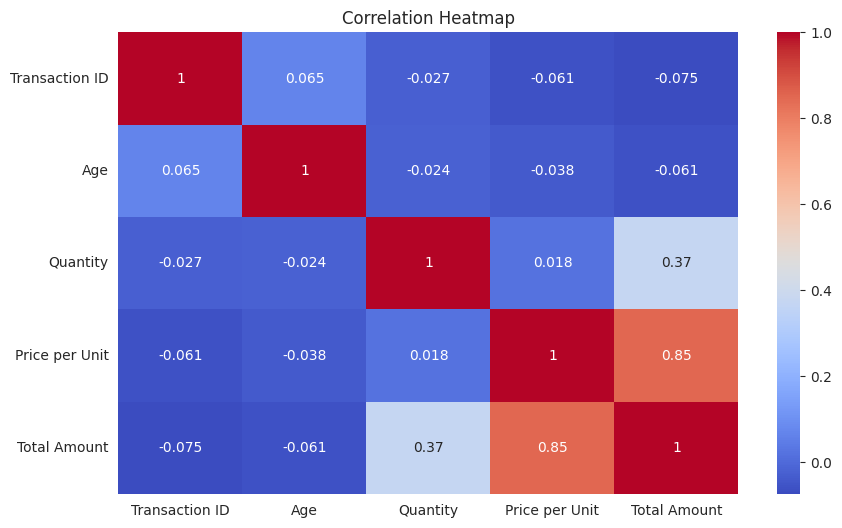

All done! Cleaned datasets saved.


In [ ]:
# Install and import libraries
!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_style("whitegrid")
%matplotlib inline

# Upload CSV files
uploaded = files.upload()  # Choose menu.csv and retail_sales_dataset.csv

# Load CSV files
menu_df = pd.read_csv("menu.csv")
sales_df = pd.read_csv("retail_sales_dataset.csv")

# Preview data
print("Menu Data Preview:")
display(menu_df.head())

print("Retail Sales Data Preview:")
display(sales_df.head())

# Inspect data
print("Menu Data Info:")
menu_df.info()
print("Missing values:\n", menu_df.isnull().sum())

print("\nRetail Sales Data Info:")
sales_df.info()
print("Missing values:\n", sales_df.isnull().sum())

print("\nDuplicates in Menu Data:", menu_df.duplicated().sum())
print("Duplicates in Sales Data:", sales_df.duplicated().sum())

# Clean data
menu_df.drop_duplicates(inplace=True)
sales_df.drop_duplicates(inplace=True)

if 'Sales' in sales_df.columns:
    sales_df['Sales'].fillna(sales_df['Sales'].mean(), inplace=True)

if 'Date' in sales_df.columns:
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Descriptive statistics
def descriptive_stats(df, column):
    print(f"Statistics for {column}:")
    print("Mean:", df[column].mean())
    print("Median:", df[column].median())
    print("Mode:", df[column].mode()[0])
    print("Standard Deviation:", df[column].std())
    print("\n")

if 'Sales' in sales_df.columns:
    descriptive_stats(sales_df, 'Sales')

# Time Series Analysis
if 'Date' in sales_df.columns and 'Sales' in sales_df.columns:
    monthly_sales = sales_df.groupby(sales_df['Date'].dt.to_period('M'))['Sales'].sum()
    monthly_sales.plot(kind='line', figsize=(12,6), title='Monthly Sales Trend')
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.show()

# Customer and Product Analysis
if 'Product' in sales_df.columns and 'Sales' in sales_df.columns:
    top_products = sales_df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
    top_products.plot(kind='bar', figsize=(12,6), title='Top Products by Sales')
    plt.xlabel("Product")
    plt.ylabel("Sales")
    plt.show()

if 'Customer_Location' in sales_df.columns:
    sns.countplot(x='Customer_Location', data=sales_df)
    plt.title("Customers by Location")
    plt.xticks(rotation=45)
    plt.show()

# Visualizations
numeric_cols = sales_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

if 'Quantity' in sales_df.columns and 'Sales' in sales_df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Quantity', y='Sales', data=sales_df)
    plt.title("Sales vs Quantity")
    plt.show()

# Save cleaned datasets
menu_df.to_csv("menu_cleaned.csv", index=False)
sales_df.to_csv("retail_sales_cleaned.csv", index=False)

print("All done! Cleaned datasets saved.")